In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
dfC = pd.read_csv('../Data/constructs_df.csv', index_col=0)
dfA = pd.read_csv('../Data/CRX_fulllength.csv', index_col=0)

In [3]:
# Calculate normalized Ef_cell values per window
# Extract window and mutation information
dfC['window'] = dfC['construct'].str.extract(r'^(\d+-\d+)')[0]
dfC['mutation'] = dfC['construct'].str.extract(r'_(.+)$')[0]

# Initialize columns for normalized values
dfC['Ef_cell_norm'] = np.nan
dfC['Ef_cell_norm_std'] = np.nan

# Get unique windows
windows = dfC['window'].unique()

for window in windows:
    # Get the WT value for this window
    wt_mask = (dfC['window'] == window) & (dfC['mutation'] == 'WT')
    
    if wt_mask.any():
        wt_ef = dfC.loc[wt_mask, 'Ef_cell'].values[0]
        wt_std = dfC.loc[wt_mask, 'Ef_cell_std'].values[0]
        
        # Get all constructs for this window
        window_mask = dfC['window'] == window
        
        # Calculate normalized values
        dfC.loc[window_mask, 'Ef_cell_norm'] = dfC.loc[window_mask, 'Ef_cell'] / wt_ef
        
        # Propagate error: if z = x/y, then σ_z = z * sqrt((σ_x/x)^2 + (σ_y/y)^2)
        mutant_ef = dfC.loc[window_mask, 'Ef_cell']
        mutant_std = dfC.loc[window_mask, 'Ef_cell_std']
        
        dfC.loc[window_mask, 'Ef_cell_norm_std'] = (mutant_ef / wt_ef) * np.sqrt(
            (mutant_std / mutant_ef)**2 + (wt_std / wt_ef)**2
        )

In [4]:
# Merge normalized_activity_score_mean and normalized_activity_score_std from dfA to dfC
# based on matching mutation column
dfC = dfC.merge(
    dfA[['mutation', 'normalized_activity_score_mean', 'normalized_activity_score_std', 'ks_fdr_pvalue', 'in_clinvar']], 
    on='mutation', 
    how='left'
)

# Calculate log2 fold change for normalized_activity_score_mean
dfC['log2fc_activity'] = np.log2(dfC['normalized_activity_score_mean'])

# Propagate error for log2 transformation: σ_log2(x) = σ_x / (x * ln(2))
dfC['log2fc_activity_std'] = dfC['normalized_activity_score_std'] / (dfC['normalized_activity_score_mean'] * np.log(2))

# Calculate log2 fold change for Ef_cell_norm
dfC['log2fc_Ef_cell'] = np.log2(dfC['Ef_cell_norm'])

# Propagate error for log2 transformation of Ef_cell_norm
dfC['log2fc_Ef_cell_std'] = dfC['Ef_cell_norm_std'] / (dfC['Ef_cell_norm'] * np.log(2))

# Perform Welch's t-test for each mutant vs WT within each window
dfC['Ef_welch_pvalue'] = np.nan

for window in windows:
    # Get WT data for this window
    wt_mask = (dfC['window'] == window) & (dfC['mutation'] == 'WT')
    
    if wt_mask.any():
        wt_ef = dfC.loc[wt_mask, 'Ef_cell'].values[0]
        wt_std = dfC.loc[wt_mask, 'Ef_cell_std'].values[0]
        wt_n = dfC.loc[wt_mask, 'n_wells'].values[0]
        
        # Get all mutants for this window
        mutant_mask = (dfC['window'] == window) & (dfC['mutation'] != 'WT')
        
        for idx in dfC[mutant_mask].index:
            mut_ef = dfC.loc[idx, 'Ef_cell']
            mut_std = dfC.loc[idx, 'Ef_cell_std']
            mut_n = dfC.loc[idx, 'n_wells']
            
            # Perform Welch's t-test using summary statistics
            t_stat, p_value = stats.ttest_ind_from_stats(
                mean1=mut_ef, std1=mut_std, nobs1=mut_n,
                mean2=wt_ef, std2=wt_std, nobs2=wt_n,
                equal_var=False
            )
            
            dfC.loc[idx, 'Ef_welch_pvalue'] = p_value

# Apply Benjamini-Hochberg FDR correction to Ef_welch_pvalue
from scipy.stats import false_discovery_control

# Get non-NaN p-values for correction
valid_pvalues_mask = dfC['Ef_welch_pvalue'].notna()
p_values = dfC.loc[valid_pvalues_mask, 'Ef_welch_pvalue'].values

# Apply FDR correction (Benjamini-Hochberg)
p_adjusted = false_discovery_control(p_values, method='bh')

# Create column and assign corrected p-values
dfC['Ef_welch_pvalue_FDR'] = np.nan
dfC.loc[valid_pvalues_mask, 'Ef_welch_pvalue_FDR'] = p_adjusted

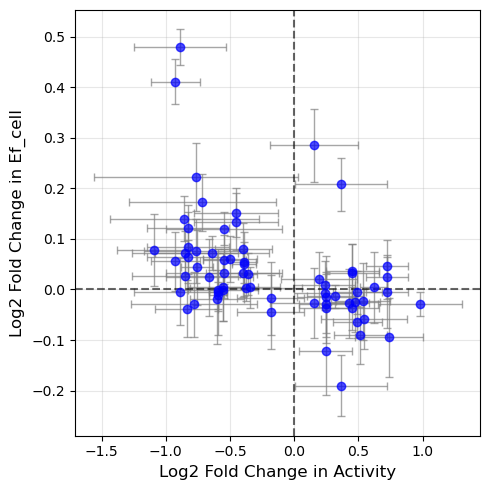

In [5]:
# Create scatter plot of log2fc_activity vs log2fc_Ef_cell
fig, ax = plt.subplots(figsize=(5, 5))

# Filter out WT constructs and rows with missing data, and only keep ClinVar variants
plot_data = dfC[(dfC['mutation'] != 'WT') & 
                dfC['log2fc_Ef_cell'].notna() & 
                dfC['log2fc_activity'].notna()].copy()

# Create scatter plot with error bars (activity on x-axis, Ef_cell on y-axis)
ax.errorbar(plot_data['log2fc_activity'],
            plot_data['log2fc_Ef_cell'], 
            xerr=plot_data['log2fc_activity_std'],
            yerr=plot_data['log2fc_Ef_cell_std'],
            fmt='o', color='blue', markersize=6, 
            ecolor='grey', alpha=0.7, capsize=3, elinewidth=1)

# Add reference lines at 0 (no change in log2 space)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

# Labels and styling
ax.set_xlabel('Log2 Fold Change in Activity', fontsize=12)
ax.set_ylabel('Log2 Fold Change in Ef_cell', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

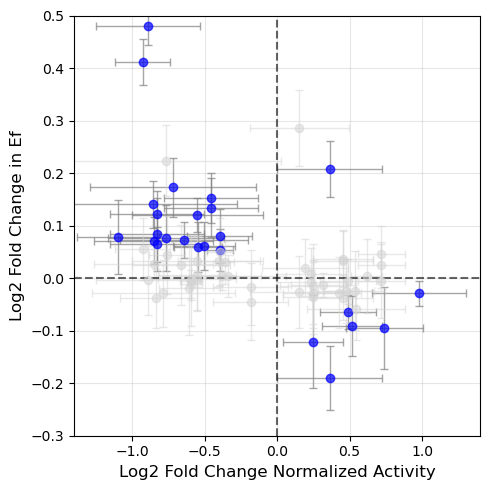

Significant points: 25
Non-significant points: 43


In [6]:
# Create scatter plot of log2fc_activity vs log2fc_Ef_cell
fig, ax = plt.subplots(figsize=(5, 5))

# Filter out WT constructs and rows with missing data, and only keep ClinVar variants
plot_data = dfC[(dfC['mutation'] != 'WT') & 
                dfC['log2fc_Ef_cell'].notna() & 
                dfC['log2fc_activity'].notna()].copy()

# Determine which points have error bars that touch x=0 or y=0
x_touches_zero = (plot_data['log2fc_activity'] - plot_data['log2fc_activity_std'] <= 0) & \
                 (plot_data['log2fc_activity'] + plot_data['log2fc_activity_std'] >= 0)
y_touches_zero = (plot_data['log2fc_Ef_cell'] - plot_data['log2fc_Ef_cell_std'] <= 0) & \
                 (plot_data['log2fc_Ef_cell'] + plot_data['log2fc_Ef_cell_std'] >= 0)
touches_zero = x_touches_zero | y_touches_zero

# Split data into significant and non-significant
significant_data = plot_data[~touches_zero]
nonsignificant_data = plot_data[touches_zero]

# Plot significant points (blue)
if len(significant_data) > 0:
    ax.errorbar(significant_data['log2fc_activity'],
                significant_data['log2fc_Ef_cell'], 
                xerr=significant_data['log2fc_activity_std'],
                yerr=significant_data['log2fc_Ef_cell_std'],
                fmt='o', color='blue', markersize=6, 
                ecolor='grey', alpha=0.7, capsize=3, elinewidth=1)

# Plot non-significant points (grey)
if len(nonsignificant_data) > 0:
    ax.errorbar(nonsignificant_data['log2fc_activity'],
                nonsignificant_data['log2fc_Ef_cell'], 
                xerr=nonsignificant_data['log2fc_activity_std'],
                yerr=nonsignificant_data['log2fc_Ef_cell_std'],
                fmt='o', color='lightgrey', markersize=6, 
                ecolor='lightgrey', alpha=0.5, capsize=3, elinewidth=1)

# Add reference lines at 0 (no change in log2 space)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-.3, .5)

# Labels and styling
ax.set_xlabel('Log2 Fold Change Normalized Activity', fontsize=12)
ax.set_ylabel('Log2 Fold Change in Ef', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Significant points: {len(significant_data)}")
print(f"Non-significant points: {len(nonsignificant_data)}")

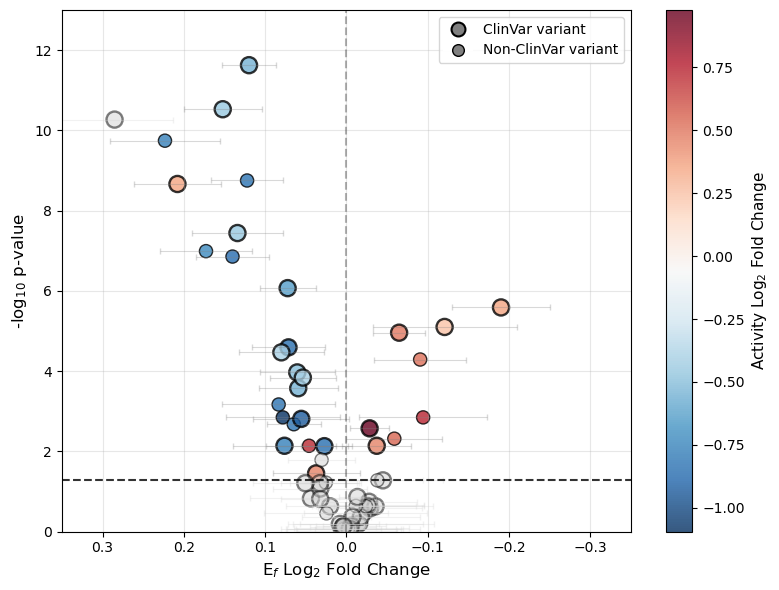

In [7]:
# Create volcano plot
fig, ax = plt.subplots(figsize=(8, 6))

# Filter for ClinVar variants with required data
volcano_data = dfC[(dfC['mutation'] != 'WT') & 
                   dfC['log2fc_Ef_cell'].notna() & 
                   dfC['Ef_welch_pvalue_FDR'].notna() &
                   dfC['log2fc_activity'].notna()].copy()

# Calculate -log10(p-value) for y-axis
volcano_data['-log10_pvalue'] = -np.log10(volcano_data['Ef_welch_pvalue_FDR'])

# Determine significance based on p-values
ef_significant = volcano_data['Ef_welch_pvalue_FDR'] < 0.05
activity_significant = volcano_data['ks_fdr_pvalue'] < 0.05
is_significant = ef_significant & activity_significant

# Split data into significant and non-significant
significant_volcano = volcano_data[is_significant]
nonsignificant_volcano = volcano_data[~is_significant]

# Plot significant points with color mapping
if len(significant_volcano) > 0:
    # Determine point sizes and edge widths based on ClinVar status
    sizes_sig = [135 if cv else 90 for cv in significant_volcano['in_clinvar']]
    edge_widths_sig = [1.7 if cv else 1 for cv in significant_volcano['in_clinvar']]
    
    scatter_sig = ax.scatter(significant_volcano['log2fc_Ef_cell'],
                            significant_volcano['-log10_pvalue'],
                            c=significant_volcano['log2fc_activity'],
                            cmap='RdBu_r', s=sizes_sig, alpha=.8, 
                            edgecolors='black', linewidths=edge_widths_sig)
    
    # Add error bars for significant points
    for idx, row in significant_volcano.iterrows():
        ax.errorbar(row['log2fc_Ef_cell'], row['-log10_pvalue'],
                   xerr=row['log2fc_Ef_cell_std'],
                   fmt='none', ecolor='grey', alpha=0.3, 
                   capsize=2, elinewidth=0.8)

# Plot non-significant points in grey
if len(nonsignificant_volcano) > 0:
    # Determine point sizes and edge widths based on ClinVar status
    sizes_nonsig = [135 if cv else 90 for cv in nonsignificant_volcano['in_clinvar']]
    edge_widths_nonsig = [1.7 if cv else 1 for cv in nonsignificant_volcano['in_clinvar']]
    
    ax.scatter(nonsignificant_volcano['log2fc_Ef_cell'],
              nonsignificant_volcano['-log10_pvalue'],
              color='lightgrey', s=sizes_nonsig, alpha=0.5, 
              edgecolors='black', linewidths=edge_widths_nonsig)
    
    # Add error bars for non-significant points
    for idx, row in nonsignificant_volcano.iterrows():
        ax.errorbar(row['log2fc_Ef_cell'], row['-log10_pvalue'],
                   xerr=row['log2fc_Ef_cell_std'],
                   fmt='none', ecolor='lightgrey', alpha=0.3, 
                   capsize=2, elinewidth=0.8)

# Add colorbar (only for significant points)
if len(significant_volcano) > 0:
    cbar = plt.colorbar(scatter_sig, ax=ax)
    cbar.set_label('Activity Log$_2$ Fold Change', fontsize=11)

# Add significance threshold line (p=0.05)
ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', 
          linewidth=1.5, alpha=0.8, label='p = 0.05')

ax.set_ylim(0, 13)
ax.set_xlim(.35, -0.35)

# Add vertical line at x=0
ax.axvline(x=0, color='black', linestyle='--', 
          linewidth=1.5, alpha=0.3)

# Labels and styling
ax.set_xlabel('E$_f$ Log$_2$ Fold Change', fontsize=12)
ax.set_ylabel('-log$_1$$_0$ p-value', fontsize=12)

# Create custom legend for point sizes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='ClinVar variant',
           markerfacecolor='grey', markersize=10, markeredgewidth=1.5, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Non-ClinVar variant',
           markerfacecolor='grey', markersize=8.4, markeredgewidth=1, markeredgecolor='black')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_14041/1638622204.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=categories, patch_artist=True,


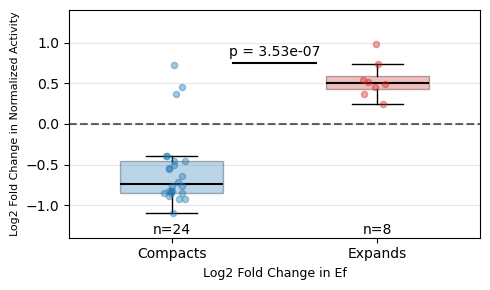

T-test results: t-statistic = -6.4947, p-value = 3.5293e-07


In [8]:
# Create boxplot comparing activity fold change for positive vs negative Ef changes
fig, ax = plt.subplots(figsize=(5, 3))

# Filter for significant points only
sig_data = volcano_data[is_significant].copy()

# Categorize by Ef_cell log2 fold change
positive_ef = sig_data[sig_data['log2fc_Ef_cell'] > 0]['log2fc_activity']
negative_ef = sig_data[sig_data['log2fc_Ef_cell'] < 0]['log2fc_activity']

# Create box plot
data_to_plot = [positive_ef, negative_ef]
categories = ['Compacts', 'Expands']

bp = ax.boxplot(data_to_plot, labels=categories, patch_artist=True,
                widths=0.5,
                boxprops=dict(facecolor='lightblue', alpha=0.3),
                medianprops=dict(color='black', linewidth=1.5),
                showfliers=False)

# Color the boxes differently
colors = ['#1f77b4', '#d62728']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add individual points with matching colors
point_colors = ['#1f77b4', '#d62728']  # Blue for Compacts, Red for Expands
for i, data in enumerate(data_to_plot):
    x_jitter = np.random.normal(i + 1, 0.04, size=len(data))
    ax.scatter(x_jitter, data, alpha=0.4, s=20, color=point_colors[i], zorder=3)

# Add reference line at 0
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

# Perform t-test between the two conditions
t_stat, p_value = stats.ttest_ind(positive_ef, negative_ef)

# Add horizontal bar and p-value annotation
y_pos = 0.75
x1, x2 = 1.3, 1.7
ax.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=1.5)

# Add p-value text in scientific notation
ax.text((x1 + x2) / 2, y_pos + 0.08, f'p = {p_value:.2e}', ha='center', fontsize=10)

ax.set_ylim(-1.4, 1.4)

# Labels and styling
ax.set_ylabel('Log2 Fold Change in Normalized Activity', fontsize=8)
ax.set_xlabel('Log2 Fold Change in Ef', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Add sample sizes
for i, data in enumerate(data_to_plot):
    ax.text(i + 1, ax.get_ylim()[0] + 0.05, f'n={len(data)}', 
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print t-test results
print(f"T-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")